# ERA5 Regional Temporal Scale Analysis 

**Purpose**: Code for preforming the regional time scale analysis. Here, we compute the decorrelation time scale for a subset of the model domain at each grid point. 

**Luke Colosi | lcolosi@ucsd.edu**

Force matplotlib plots to display directly within the output cell of the notebook

In [1]:
%matplotlib inline

Import python libraries

In [2]:
import sys
import xarray as xr
import numpy as np
import matplotlib.pyplot as plt 
from netCDF4 import Dataset, num2date
from datetime import datetime
import cartopy.crs as ccrs
import cartopy.feature as cfeature
import os
import cmocean
import matplotlib.dates as mdates
from matplotlib.ticker import FuncFormatter

# Set path to access python functions
ROOT = '/Users/lukecolosi/Desktop/projects/graduate_research/Gille_lab/'
sys.path.append(ROOT + 'AirSeaCoupling/tools/')

#--- Other Functions ---# 
import cartopy_figs as cart
from autocorr import compute_autocorr_optimize, compute_decor_scale_optimize, segment_time_series
from lsf import unweighted_lsf, detrend
from plotScaleAnalysis import month_fmt

Set data analysis parameters

In [3]:
# Set processing parameters
option_plot          = 0          # Specifies if supplementary plots are plotted
option_var           = 'u_wind'
option_unc           = 1

# Set time and space parameters
T            = 1*(60)*(60)                   # Spcifies the time interval for model run. Units: seconds  
lat_bnds     = [33, 35]                      # Specifies the latitude bounds for the region to analyze
lon_bnds     = [-123 % 360, -120 % 360]      # Specifies the longitude bounds for the region to analyze

# Set path to project directory
PATH = ROOT + 'AirSeaCoupling/data/era5/'
PATH_bathy  = ROOT + 'AirSeaCoupling/data/bathymetry/'

# Set plotting parameters 
fontsize = 16

plt.rcParams.update({
    "font.size": fontsize,         # Fontsize
    "text.usetex": True,           # Use LaTeX for all text
    "font.family": "serif",        # Optional: match LaTeX font
    "text.latex.preamble": r"\usepackage{amsmath}"  # Optional: load extra LaTeX packages
})

Load mitgcm data netcdf files 

In [4]:
# Read in data 
filename = PATH + "ERA5_wind_vel_2016-2017.nc"
nc = Dataset(filename, 'r')

# Extract data variables
lon = nc.variables['lon'][:]
lat = nc.variables['lat'][:]
time =  num2date(nc.variables['time'][:], nc.variables['time'].units)

u_wind = nc.variables['U_wind'][:]
v_wind = nc.variables['V_wind'][:]

# Convert cftime.DatetimeGregorian to Python datetime objects
time_dt = np.array([datetime(d.year, d.month, d.day, d.hour, d.minute, d.second) for d in time])

Compute wind speed

In [5]:
wind_speed = np.sqrt(u_wind**2 + v_wind**2)

Read in bathymetry data

In [6]:
# Load bathymetry data 
filename = PATH_bathy + "topo_25.1.nc"
ds_bathy = xr.open_dataset(filename, engine="netcdf4")

# Extract data variables
lon_b = ds_bathy["lon"]  # Longitude
lat_b = ds_bathy["lat"]  # Latitude
bathy = ds_bathy["z"]    # Elevation/Bathymetry

# Convert convesion of longitude (neg from the prime meridian to positive definite wrapping around the earth)
lon_n = lon_b % 360

# Set max and min values 
lon_min = lon_bnds[0]
lon_max = lon_bnds[1]
lat_min = lat_bnds[0]
lat_max = lat_bnds[1]

# Extract data from bathymetry 
lon_grid = lon_n[(lon_n >= lon_min) & (lon_n <= lon_max)]
lat_grid = lat_b[(lat_b >= lat_min) & (lat_b <= lat_max)]
bathy_grid   = bathy[(lat_b >= lat_min) & (lat_b <= lat_max),(lon_n >= lon_min) & (lon_n <= lon_max)]

Plot the spatial domain

/Users/lukecolosi/miniforge3/envs/ocean_scales/lib/python3.13/site-packages/cartopy/mpl/geoaxes.py:1631: UserWarning: The following kwargs were not used by contour: 'shading'
  result = super().contourf(*args, **kwargs)


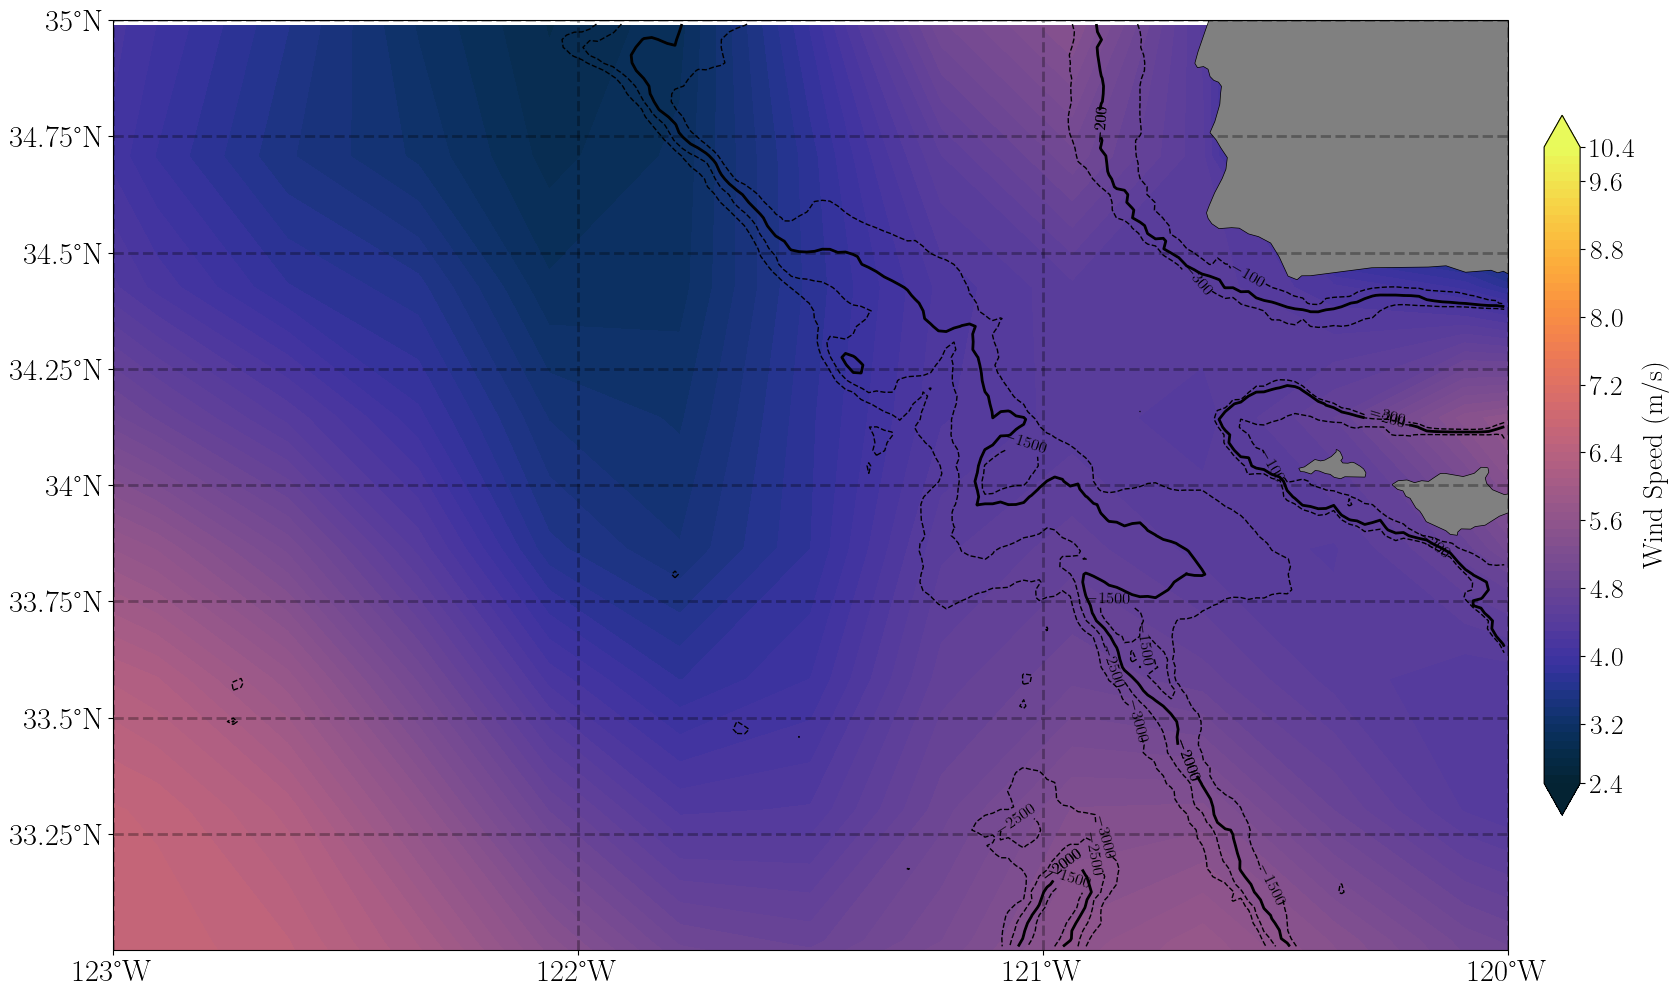

In [7]:
# Set plotting parameters
projection = ccrs.PlateCarree(central_longitude=0.0)
xticks = [-123, -122, -121, -120]
yticks = [33.25, 33.50, 33.75, 34.00, 34.25, 34.50, 34.75, 35.00]
resolution = "10m"
bounds = np.arange(0,360+40,40)
lon_min = -123
lon_max = -120
lat_min = 33
lat_max = 35

# Specify data specific attributes 
cmap = cmocean.cm.thermal
label = r'Wind Speed (m/s)'
levels = np.arange(2.5,10 + 0.1,0.1)

# Create figure
fig, axes = plt.subplots(1,1, figsize=(18, 20), subplot_kw={"projection": projection})

# Set figure axes 
cart.set_subplots(axes, projection, resolution, lon_min=lon_min, lon_max=lon_max, lat_min=lat_min, lat_max=lat_max) 

# Plot potential temperature
mesh = axes.contourf(
    lon, lat, wind_speed[0,:,:], levels=levels,
    transform=ccrs.PlateCarree(),
    cmap=cmap,  
    shading="auto", 
    extend='both'
)

# Plot depth contour lines
level_innershelf = np.arange(-300,0,100)
levels_midshelf = np.arange(-3000,-1000,500)
contour1 = axes.contour(lon_grid, lat_grid, bathy_grid,levels=levels_midshelf, colors='black', linewidths=1, linestyles='dashed')
contour2 = axes.contour(lon_grid, lat_grid, bathy_grid,levels=[-2000], colors='black', linewidths=2, linestyles='solid')
contour3 = axes.contour(lon_grid, lat_grid, bathy_grid,levels=level_innershelf, colors='black', linewidths=1, linestyles='dashed')
contour4 = axes.contour(lon_grid, lat_grid, bathy_grid,levels=[-200], colors='black', linewidths=2, linestyles='solid')
plt.clabel(contour1, fontsize=12)
plt.clabel(contour2, fontsize=12)
plt.clabel(contour3, fontsize=12)
plt.clabel(contour4, fontsize=12)

# Set grid ticks 
cart.set_grid_ticks(
    axes,
    projection=ccrs.PlateCarree(),
    xticks=xticks,
    yticks=yticks,
    xlabels=True,
    ylabels=True,
    grid=True,
    fontsize=22,
    color="black",
)

# Create colormap
cax = plt.axes([0.92, 0.33, 0.02, 0.35])
cart.set_cbar(
    mesh,
    cax,
    fig,
    orientation="vertical",
    extend="neither",
    cbar_label=label,
    nbins=10,
    fontsize=20,
    cbar_ticks=[],
    task="regular",
)

# Show the plot
plt.show()

Compute the monthly climatology

In [8]:
# Grab one time series
data_ts = wind_speed[:,0,0]

# Convert to seconds since start time
t0 = time_dt[0]
time_elapsed = np.array([(t - t0).total_seconds() for t in time_dt])
 
# Convert time array to year and month integers
years  = np.array([t.year for t in time_dt])
months = np.array([t.month for t in time_dt])

# Combine into "year-month" unique identifiers (e.g., 202301 for Jan 2023)
yearmonth = years * 100 + months
unique_months = np.unique(yearmonth)

# Preallocate masked arrays for results
monthly_mean  = np.ma.masked_all((len(unique_months)))
monthly_var   = np.ma.masked_all((len(unique_months)))
monthly_std   = np.ma.masked_all((len(unique_months)))
monthly_stdm  = np.ma.masked_all((len(unique_months)))
monthly_stdv  = np.ma.masked_all((len(unique_months)))
Lt_days           = np.ma.masked_all((len(unique_months)))

# Loop over moorings and months
for im, ym in enumerate(unique_months):

    # Select all time indices belonging to this month
    idx = np.where(yearmonth == ym)[0]
    if idx.size == 0:
        continue
    
    # Extract MLD values for that mooring and month
    vals = data_ts[idx]
    itime = time_elapsed[idx]

    # Skip if all masked
    if vals.mask.all():
        continue

    # Compute monthly mean and variance ignoring masked values
    monthly_mean[im] = np.ma.mean(vals)
    monthly_var[im]  = np.ma.var(vals,ddof=1)
    monthly_std[im]  = np.ma.std(vals,ddof=1)

    # Compute the decorrelation scale 
    vals_dt = detrend(vals, itime, mean = 0)
    autocorr, _, _, _, lag_time, _ = compute_autocorr_optimize(vals_dt, itime, len(itime), 'biased', 0)
    Lt = compute_decor_scale_optimize(autocorr,lag_time,T,'unbiased',0)

    # Convert decorrelation scale to units of days
    Lt_days[im] = Lt*(1/60)*(1/60)*(1/24)

    # Compute the number of degrees of freedom at each site
    T_days = T*(1/60)*(1/60)*(1/24)
    n_d = Lt_days[im]/T_days
    N_eff = len(itime)/n_d

    # Compute the standard error of the mean and variance
    monthly_stdm[im] = monthly_std[im] / np.sqrt(N_eff)
    monthly_stdv[im] = monthly_var[im] * np.sqrt(2/(N_eff-1))

# Create simple arrays of the corresponding (year, month)
month_years = unique_months // 100
month_nums  = unique_months % 100

# Combine into datetime objects (using the first day of each month)
monthly_time = np.array([
    datetime(int(y), int(m), 1) for y, m in zip(month_years, month_nums)
])

Plot the monthly climatology

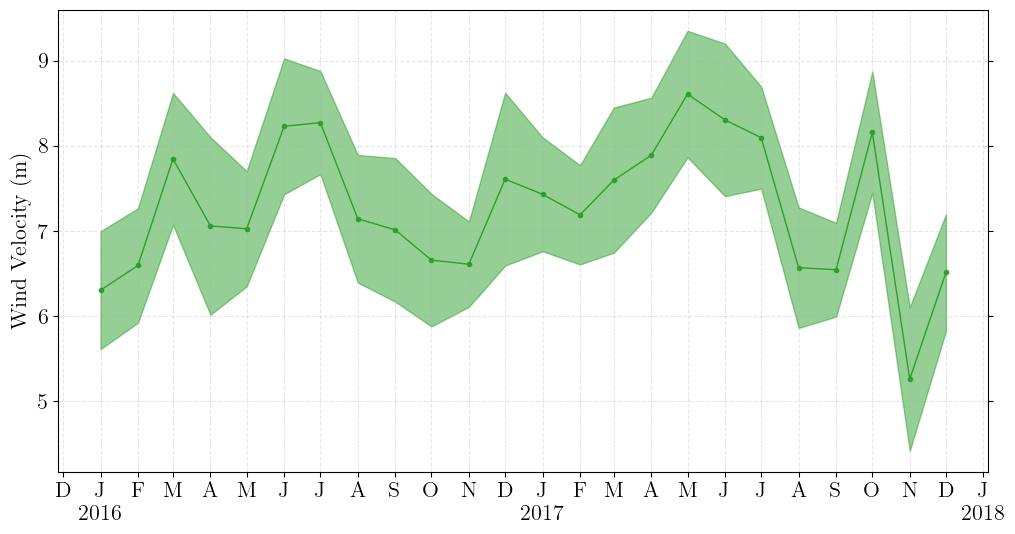

In [10]:
#Create figure
fig,ax = plt.subplots(figsize=(12, 6))

# Plot mixed layer depth variance for each mooring
ax.plot(monthly_time,monthly_mean, '.-', color='tab:green', lw=1)

# Plot standard error of the variance  for each mooring
ax.fill_between(monthly_time, monthly_mean - monthly_stdm, monthly_mean + monthly_stdm, color='tab:green', alpha=0.5)

# Set axis attributes
ax.set_ylabel(r"Wind Velocity (m)")
ax.tick_params(top=False, bottom=True, left=True, right=True,
                direction='out', length=3.5)
ax.xaxis.set_major_locator(mdates.MonthLocator())
ax.xaxis.set_major_formatter(FuncFormatter(month_fmt))
ax.grid(True,linestyle='--',alpha=0.3)

Preform scale analysis

In [8]:
# Set variable to analyze 
if option_var == 'wind_speed': 
    data = wind_speed
elif option_var == 'u_wind': 
    data = u_wind
elif option_var == 'v_wind': 
    data = v_wind

# Hanles option for computing uncertainties or not
if option_unc == True: 
    
    # Set parameters
    w1, w2        = [(2*np.pi)/31557600, (1/2)*(2*np.pi)/31557600]      # Radian Frequency for annual and semi-annual cycles. Units: rad/sec
    segment_years = 1 
    overlap       = 0.5

    # Obtain a example segment 
    segments = segment_time_series(time_dt, data[:,0,0], segment_years=segment_years, overlap=overlap)

    # Set dimensions     
    nseg,ntime  = np.shape(segments)[0], np.shape(segments)[2]
    _,nlat,nlon = np.shape(data)

    # Set autocorrelation parameters
    lag       = ntime
    norm      = 0
    estimator = 'biased'

    # Convert to seconds since start time
    t0 = time_dt[0]
    time_elapsed = np.array([(t - t0).total_seconds() for t in time_dt])

    # Initialize arrays 
    Lt             = np.zeros((nlat,nlon))
    Lt_stdm        = np.zeros((nlat,nlon))
    cn_lon = 0 

    # Loop through longitude 
    for ilon in range(0,nlon):
        
        # Set progress bar
        progress = (ilon + 1) / (len(lon)-1)
        sys.stdout.write(f"\rProgress: {progress:.1%}")
        sys.stdout.flush()

        # Set latitude counter 
        cn_lat = 0

        # Loop through latitude
        for ilat in range(0,nlat):
            
            # Initialize the ith time series 
            data_ts = data[:,ilat,ilon]

            # Try statement to handle masked values associated with land
            try:

                # Remove annual and semi-annual cycle 
                hfit, x_data, x_data_sigma, _ = unweighted_lsf(data_ts, time_elapsed, parameters = 2, freqs = np.array([w1,w2]), sigma = None)
                data_ts_rm = data_ts - hfit

                # Segment the time series 
                segments = segment_time_series(time_dt, data_ts_rm, segment_years=segment_years, overlap=overlap)

                # Initialize arrays
                autocorr_seg   = np.zeros((nseg,ntime))
                time_scale_seg = np.zeros((nseg,ntime))

                # Loop through segments
                for i, (tseg, dseg) in enumerate(segments):

                    # Compute the elapsed time from beginning of segmented time series (units: seconds)
                    t0 = tseg[0]
                    time_elapsed_seg = np.array([(t - t0).total_seconds() for t in tseg])
                    
                    # Detrend data record 
                    data_dt = detrend(dseg, time_elapsed_seg, mean = 0)

                    # Compute autocorrelation function
                    lag = len(time_elapsed_seg)
                    autocorr_seg[i,:], _, _, _, time_scale_seg[i,:], _ = compute_autocorr_optimize(data_dt, time_elapsed_seg, lag, estimator, norm)

                # Compute the mean autocorrelation function 
                meanAutocorr = np.nanmean(autocorr_seg, axis=0)

                # Compute the standard deviation and the number of samples 
                stdAutocorr = np.nanstd(autocorr_seg, axis=0, ddof=1)
                nAutocorr   = np.count_nonzero(~np.isnan(autocorr_seg), axis=0)

                # Compute the standard error of the mean (assuming that each data point is an independent observations)
                stdmAutocorr   = stdAutocorr/np.sqrt(nAutocorr)

                # Compute the decorrelation scale 
                Lt[ilat,ilon]  = compute_decor_scale_optimize(meanAutocorr,time_scale_seg[0,:],T,'unbiased',norm)

                # Estimate the decorrelation scale's uncertainty by perturbing the autocorrelation function by 1 standard deviation
                Lt_ustd = compute_decor_scale_optimize(meanAutocorr + stdmAutocorr ,time_scale_seg[0,:] ,T,'unbiased',norm)
                Lt_lstd = compute_decor_scale_optimize(meanAutocorr - stdmAutocorr ,time_scale_seg[0,:] ,T,'unbiased',norm)

                # Compute the average standard error 
                std_upper = Lt_ustd - Lt[ilat,ilon]
                std_lower = abs(Lt_lstd - Lt[ilat,ilon])
                Lt_stdm[ilat,ilon]  = np.mean([std_upper, std_lower])

            except Exception: 

                # Print warining message 
                print('Masked time series! Skipping grid point')

            # Set latitude counter
            cn_lat = cn_lat + 1

        # Set longitude counter
        cn_lon = cn_lon + 1

    # Convert time scale to units of days
    Lt_days      = Lt*(1/60)*(1/60)*(1/24)
    Lt_stdm_days = Lt_stdm*(1/60)*(1/60)*(1/24)

else:

    # Set parameters
    ntime,nlat,nlon = np.shape(data)
    lag = ntime
    w1, w2 = [(2*np.pi)/31557600, (1/2)*(2*np.pi)/31557600]      # Radian Frequency for annual and semi-annual cycles. Units: rad/sec
    estimator = 'biased'

    # Convert to seconds since start time
    t0 = time_dt[0]
    time_elapsed = np.array([(t - t0).total_seconds() for t in time_dt])

    # Initialize arrays 
    Lt             = np.zeros((nlat,nlon))
    cn_lon = 0 

    # Loop through longitude 
    for ilon in range(0,nlon):
        
        # Set progress bar
        progress = (ilon + 1) / (len(lon)-1)
        sys.stdout.write(f"\rProgress: {progress:.1%}")
        sys.stdout.flush()

        # Set latitude counter 
        cn_lat = 0

        # Loop through latitude
        for ilat in range(0,nlat):
            
            # Initialize the ith time series 
            data_ts = data[:,ilat,ilon]

            # Try statement to handle masked values associated with land
            try:

                # Remove annual and semi-annual cycle 
                hfit, x_data, x_data_sigma, _ = unweighted_lsf(data_ts, time_elapsed, parameters = 2, freqs = np.array([w1,w2]), sigma = None)
                data_ts_rm = data_ts - hfit

                # Detrend data record 
                data_dt = detrend(data_ts_rm, time_elapsed, mean = 0)

                # Compute autocorrelation function
                autocorr, _, _, _, time_scale, _ = compute_autocorr_optimize(data_dt, time_elapsed, lag, estimator, 0)

                # Compute the decorrelation scale
                Lt[cn_lat,cn_lon] = compute_decor_scale_optimize(autocorr,time_scale,T,'unbiased',0)

            except Exception: 

                # Print warining message 
                print('Masked time series! Skipping grid point')

            # Set latitude counter
            cn_lat = cn_lat + 1

        # Set longitude counter
        cn_lon = cn_lon + 1

    # Convert time scale to units of days
    Lt_days = Lt*(1/60)*(1/60)*(1/24)

Progress: 106.2%

Plot the spatial map of the temporal decorrelation scale 

/Users/lukecolosi/miniforge3/envs/ocean_scales/lib/python3.13/site-packages/cartopy/mpl/geoaxes.py:1631: UserWarning: The following kwargs were not used by contour: 'shading'
  result = super().contourf(*args, **kwargs)


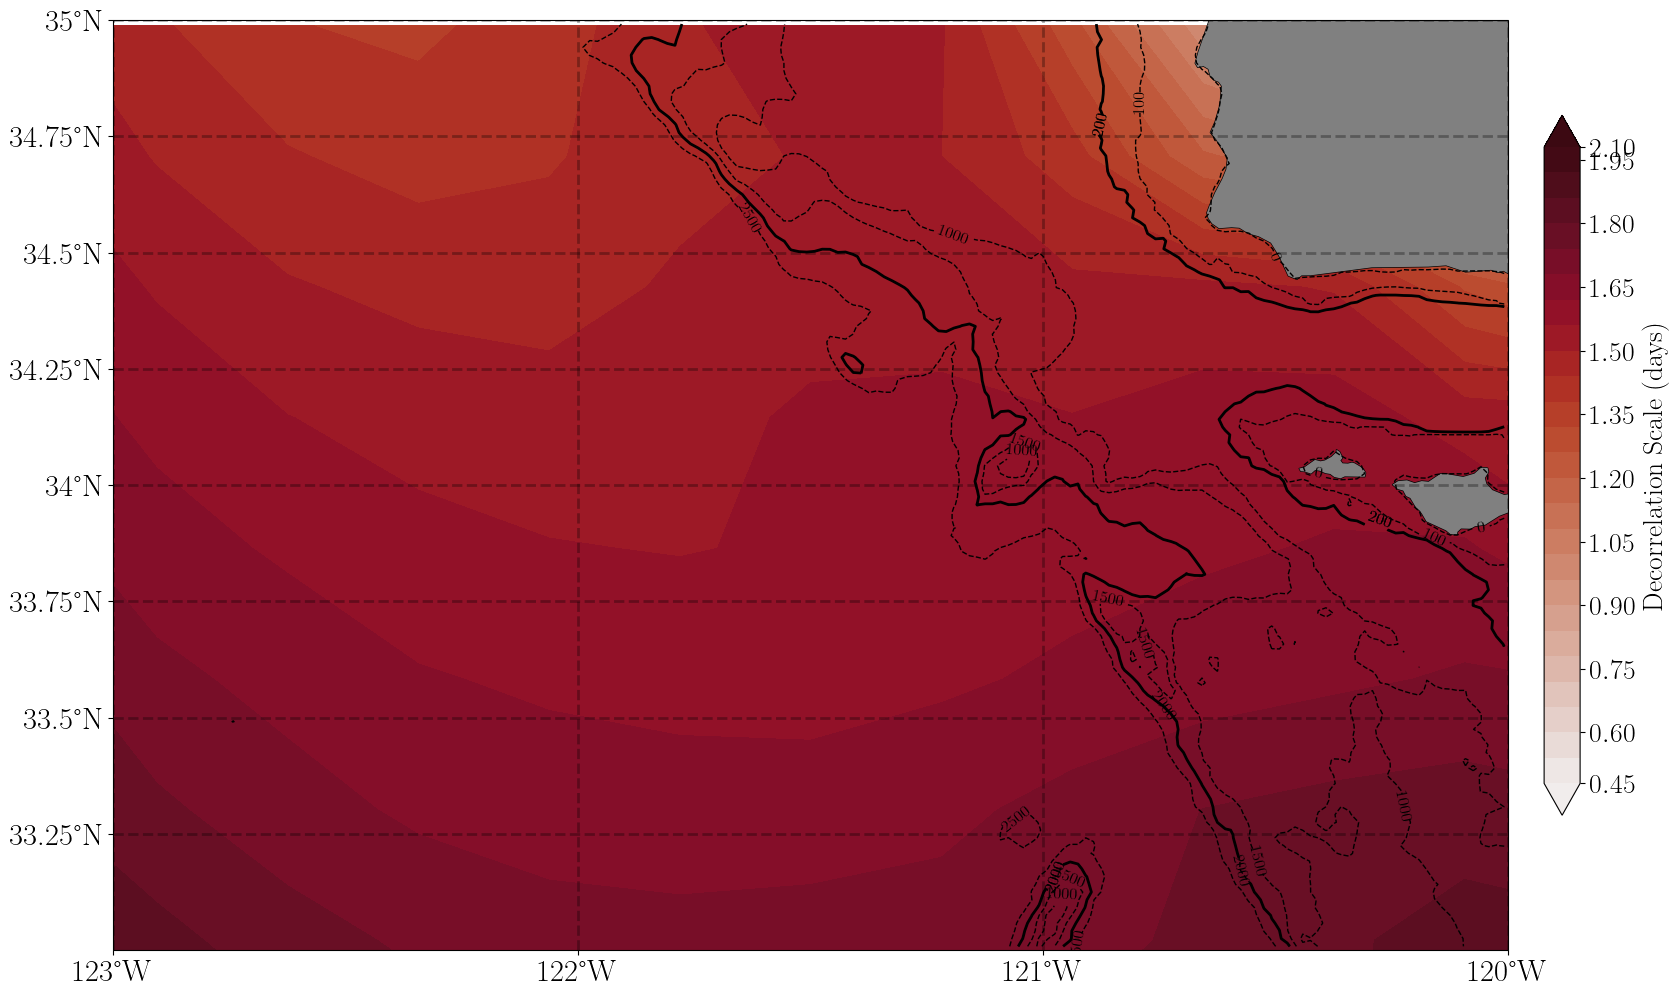

In [9]:
# Set plotting parameters 
#levels = np.arange(15,40 + 0.5,0.5) 

# Create figure
fig, axes = plt.subplots(1,1, figsize=(18, 20), subplot_kw={"projection": projection})

# Set figure axes 
cart.set_subplots(axes, projection, resolution, lon_min=lon_min, lon_max=lon_max, lat_min=lat_min, lat_max=lat_max) 

# Plot temporal decorrelation scale
mesh = axes.contourf(
    lon, lat, Lt_days, levels=30,
    transform=ccrs.PlateCarree(),
    cmap=cmocean.cm.amp,  
    shading="auto", 
    extend = 'both'
)

# Plot depth contour lines
level_innershelf = np.arange(0,300,100)
levels_midshelf = np.arange(1000,3000,500)
contour1 = axes.contour(lon_grid, lat_grid, -1*(bathy_grid),levels=levels_midshelf, colors='black', linewidths=1, linestyles='dashed')
contour2 = axes.contour(lon_grid, lat_grid, -1*(bathy_grid),levels=[2000], colors='black', linewidths=2, linestyles='solid')
contour3 = axes.contour(lon_grid, lat_grid, -1*(bathy_grid),levels=level_innershelf, colors='black', linewidths=1, linestyles='dashed')
contour4 = axes.contour(lon_grid, lat_grid, -1*(bathy_grid),levels=[200], colors='black', linewidths=2, linestyles='solid')
plt.clabel(contour1, fontsize=12)
plt.clabel(contour2, fontsize=12)
plt.clabel(contour3, fontsize=12)
plt.clabel(contour4, fontsize=12)

# Set grid ticks 
cart.set_grid_ticks(
    axes,
    projection=ccrs.PlateCarree(),
    xticks=xticks,
    yticks=yticks,
    xlabels=True,
    ylabels=True,
    grid=True,
    fontsize=22,
    color="black",
)

# Create colormap
cax = plt.axes([0.92, 0.33, 0.02, 0.35])
cart.set_cbar(
    mesh,
    cax,
    fig,
    orientation="vertical",
    extend="both",
    cbar_label=r'Decorrelation Scale (days)',
    nbins=10,
    fontsize=20,
    cbar_ticks=[],
    task="regular",
)

# Show the plot
plt.show()

Plot the standard error of the mean

/Users/lukecolosi/miniforge3/envs/ocean_scales/lib/python3.13/site-packages/cartopy/mpl/geoaxes.py:1631: UserWarning: The following kwargs were not used by contour: 'shading'
  result = super().contourf(*args, **kwargs)


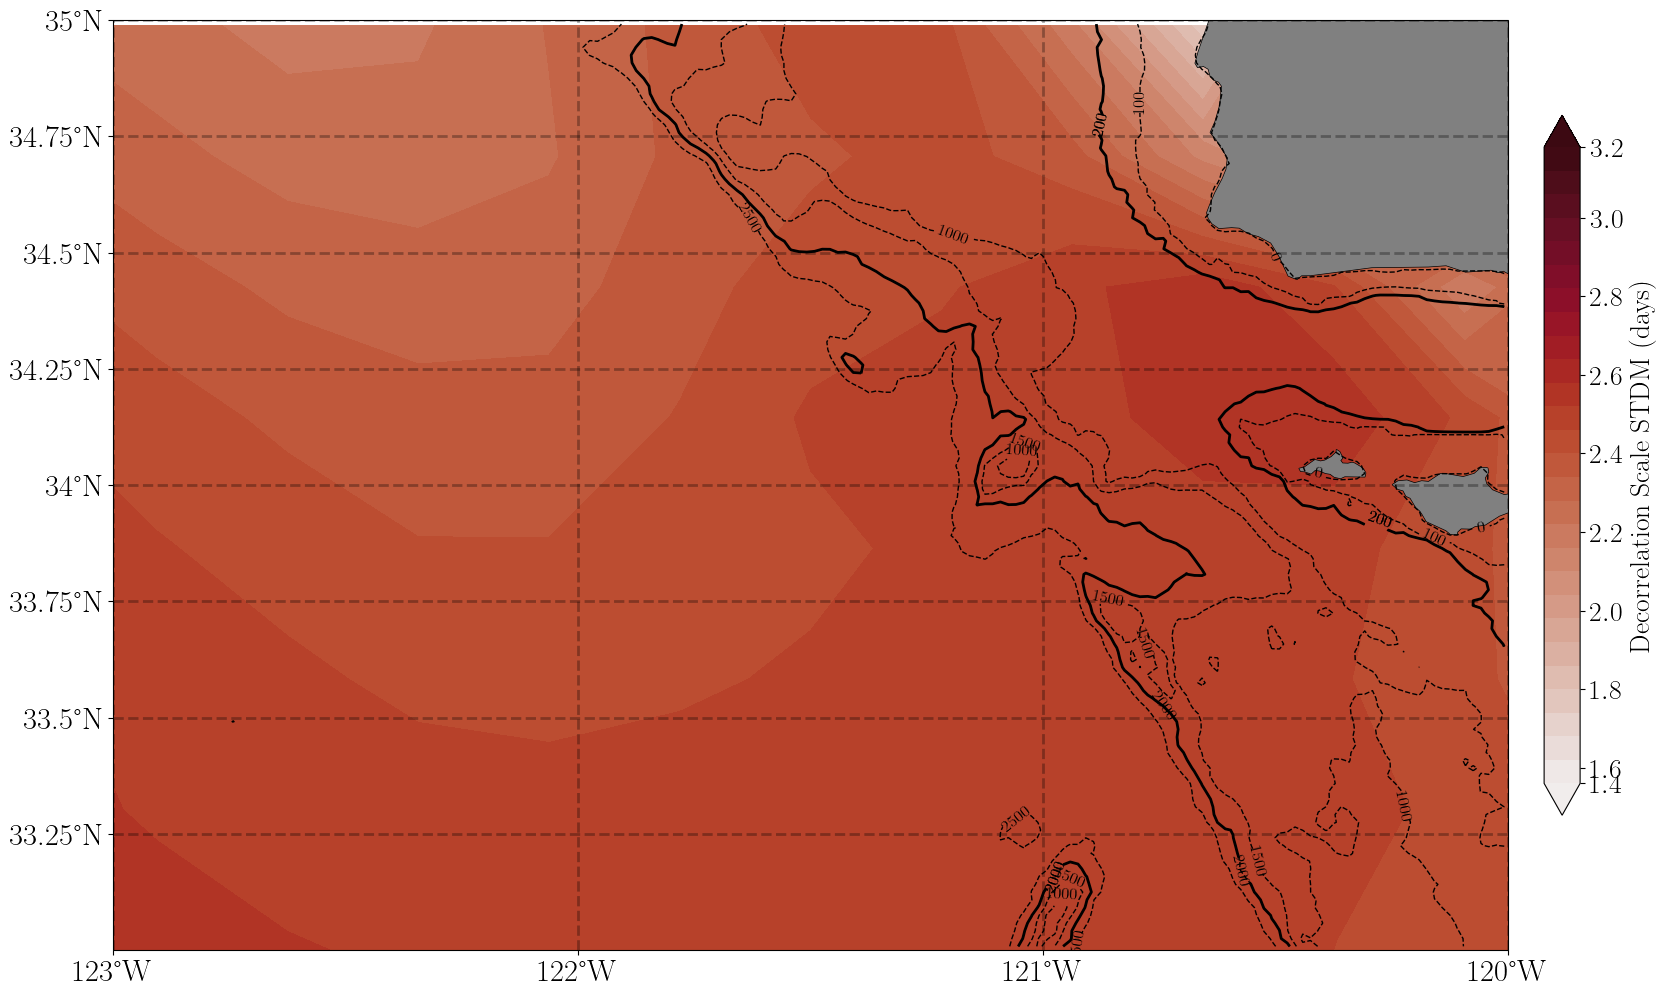

In [10]:
# Set plotting parameters 
levels = np.arange(15,40 + 0.5,0.5) 

# Create figure
fig, axes = plt.subplots(1,1, figsize=(18, 20), subplot_kw={"projection": projection})

# Set figure axes 
cart.set_subplots(axes, projection, resolution, lon_min=lon_min, lon_max=lon_max, lat_min=lat_min, lat_max=lat_max) 

# Plot temporal decorrelation scale
mesh = axes.contourf(
    lon, lat, Lt_stdm_days, levels=30,
    transform=ccrs.PlateCarree(),
    cmap=cmocean.cm.amp,  
    shading="auto", 
    extend = 'both'
)

# Plot depth contour lines
level_innershelf = np.arange(0,300,100)
levels_midshelf = np.arange(1000,3000,500)
contour1 = axes.contour(lon_grid, lat_grid, -1*(bathy_grid),levels=levels_midshelf, colors='black', linewidths=1, linestyles='dashed')
contour2 = axes.contour(lon_grid, lat_grid, -1*(bathy_grid),levels=[2000], colors='black', linewidths=2, linestyles='solid')
contour3 = axes.contour(lon_grid, lat_grid, -1*(bathy_grid),levels=level_innershelf, colors='black', linewidths=1, linestyles='dashed')
contour4 = axes.contour(lon_grid, lat_grid, -1*(bathy_grid),levels=[200], colors='black', linewidths=2, linestyles='solid')
plt.clabel(contour1, fontsize=12)
plt.clabel(contour2, fontsize=12)
plt.clabel(contour3, fontsize=12)
plt.clabel(contour4, fontsize=12)

# Set grid ticks 
cart.set_grid_ticks(
    axes,
    projection=ccrs.PlateCarree(),
    xticks=xticks,
    yticks=yticks,
    xlabels=True,
    ylabels=True,
    grid=True,
    fontsize=22,
    color="black",
)

# Create colormap
cax = plt.axes([0.92, 0.33, 0.02, 0.35])
cart.set_cbar(
    mesh,
    cax,
    fig,
    orientation="vertical",
    extend="both",
    cbar_label=r'Decorrelation Scale STDM (days)',
    nbins=10,
    fontsize=20,
    cbar_ticks=[],
    task="regular",
)

# Show the plot
plt.show()

## TEST

Progress: 6.2%

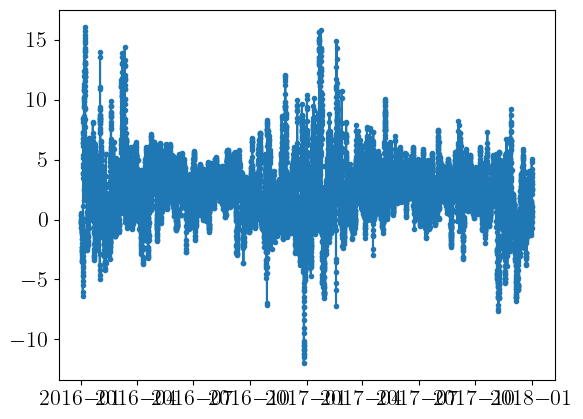

In [ ]:

# Set parameters
w1, w2        = [(2*np.pi)/31557600, (1/2)*(2*np.pi)/31557600]      # Radian Frequency for annual and semi-annual cycles. Units: rad/sec
segment_years = 1 
overlap       = 0.5

# Obtain a example segment 
segments = segment_time_series(time_dt, data[:,0,0], segment_years=segment_years, overlap=overlap)

# Set dimensions     
nseg,ntime  = np.shape(segments)[0], np.shape(segments)[2]
_,nlat,nlon = np.shape(data)

# Set autocorrelation parameters
lag       = ntime
norm      = 0
estimator = 'biased'

# Convert to seconds since start time
t0 = time_dt[0]
time_elapsed = np.array([(t - t0).total_seconds() for t in time_dt])

# Initialize arrays 
Lt             = np.zeros((nlat,nlon))
Lt_stdm        = np.zeros((nlat,nlon))
cn_lon = 0 

# Loop through longitude 
for ilon in range(0,1):
    
    # Set progress bar
    progress = (ilon + 1) / (len(lon)-1)
    sys.stdout.write(f"\rProgress: {progress:.1%}")
    sys.stdout.flush()

    # Set latitude counter 
    cn_lat = 0

    # Loop through latitude
    for ilat in range(0,1):
        
        # Initialize the ith time series 
        data_ts = data[:,ilat,ilon]

        # Try statement to handle masked values associated with land
        try:

            # Remove annual and semi-annual cycle 
            hfit, x_data, x_data_sigma, _ = unweighted_lsf(data_ts, time_elapsed, parameters = 2, freqs = np.array([w1,w2]), sigma = None)
            data_ts_rm = data_ts - hfit

            # Segment the time series 
            segments = segment_time_series(time_dt, data_ts, segment_years=segment_years, overlap=overlap)

            # Initialize arrays
            autocorr_seg   = np.zeros((nseg,ntime))
            time_scale_seg = np.zeros((nseg,ntime))

            # Loop through segments
            for i, (tseg, dseg) in enumerate(segments):

                # Compute the elapsed time from beginning of segmented time series (units: seconds)
                t0 = tseg[0]
                time_elapsed_seg = np.array([(t - t0).total_seconds() for t in tseg])
                
                # Detrend data record 
                data_dt = detrend(dseg, time_elapsed_seg, mean = 0)

                # Compute autocorrelation function
                lag = len(time_elapsed_seg)
                autocorr_seg[i,:], _, _, _, time_scale_seg[i,:], _ = compute_autocorr_optimize(data_dt, time_elapsed_seg, lag, estimator, norm)

            # Compute the mean autocorrelation function 
            meanAutocorr = np.nanmean(autocorr_seg, axis=0)

            # Compute the standard deviation and the number of samples 
            stdAutocorr = np.nanstd(autocorr_seg, axis=0, ddof=1)
            nAutocorr   = np.count_nonzero(~np.isnan(autocorr_seg), axis=0)

            # Compute the standard error of the mean (assuming that each data point is an independent observations)
            stdmAutocorr   = stdAutocorr/np.sqrt(nAutocorr)

            # Compute the decorrelation scale 
            Lt[ilat,ilon]  = compute_decor_scale_optimize(meanAutocorr,time_scale_seg[0,:],T,'unbiased',norm)

            # Estimate the decorrelation scale's uncertainty by perturbing the autocorrelation function by 1 standard deviation
            Lt_ustd = compute_decor_scale_optimize(meanAutocorr + stdmAutocorr ,time_scale_seg[0,:] ,T,'unbiased',norm)
            Lt_lstd = compute_decor_scale_optimize(meanAutocorr - stdmAutocorr ,time_scale_seg[0,:] ,T,'unbiased',norm)

            # Compute the average standard error 
            std_upper = Lt_ustd - Lt[ilat,ilon]
            std_lower = abs(Lt_lstd - Lt[ilat,ilon])
            Lt_stdm[ilat,ilon]  = np.mean([std_upper, std_lower])

        except Exception: 

            # Print warining message 
            print('Masked time series! Skipping grid point')

        # Set latitude counter
        cn_lat = cn_lat + 1

    # Set longitude counter
    cn_lon = cn_lon + 1

# Convert time scale to units of days
Lt_days      = Lt*(1/60)*(1/60)*(1/24)
Lt_stdm_days = Lt_stdm*(1/60)*(1/60)*(1/24)

In [30]:
# Convert to days
time_scale_days = time_scale_seg[0,:] * (1/60) * (1/60) * (1/24)

# Create figure
fig,ax = plt.subplots(figsize=(10,6))

# Plot the autocorrelation from each window
ax.plot(time_scale_days,autocorr_seg.T,color='grey',alpha=0.5)

# Plot the mean autocorrelation and its uncertainty
ax.plot(time_scale_days,meanAutocorr,'k-',lw=2)
ax.fill_between(time_scale_days,meanAutocorr + stdmAutocorr, meanAutocorr - stdmAutocorr, alpha=0.5,color='k')

# Set axis attributes
ax.set_xlim(0,10)
#ax.set_ylim(-0.4,1)
ax.set_xlabel(r'Time Lag (days)')
ax.set_ylabel(r"Autocorrelation")
ax.grid(ls='--',lw=1.0,alpha=0.5)

NameError: name 'time_scale_seg' is not defined

In [27]:
# Import library 
from spectra import rotary_spectrum_welch, spectrum1D_frequency

# Grab data from one grid point
u_tmp = u_wind[:,0,0]
v_tmp = v_wind[:,0,0]

# Set parameters
ntime = np.shape(u_tmp)[0]
dt = time_dt[1] - time_dt[0]
M = 40                                                       # Specifies number of windows to divide the data into for the Welch method
p = ntime // M                                               # Specifies window length, i.e., number of data points in each segment
nfft = (p // 2 + 1) if (p % 2 == 0) else ((p - 1) // 2)      # Specifies number of positive frequency bins in the resulting power spectrum
units = 'Hz'                                                 # Specifies the units of the frequency vector 

# Compute the elapsed time from beginning of segmented time series (units: seconds)
t0 = time_dt[0]
time_elapsed = np.array([(t - t0).total_seconds() for t in time_dt])

# Compute the rotary power spectra 
psd_plus_ccw, psd_minus_cw, f_cpd, CIp_ccw, CIm_cw, var_rot = rotary_spectrum_welch(u_tmp, v_tmp, T, M, units='cpd')

# Compute eddy Kinetic energy spectrum 
psd_u, f_cps, CI_u, _ = spectrum1D_frequency(u_tmp, T, M, units)
psd_v, f_cps, CI_v, _ = spectrum1D_frequency(v_tmp, T, M, units)

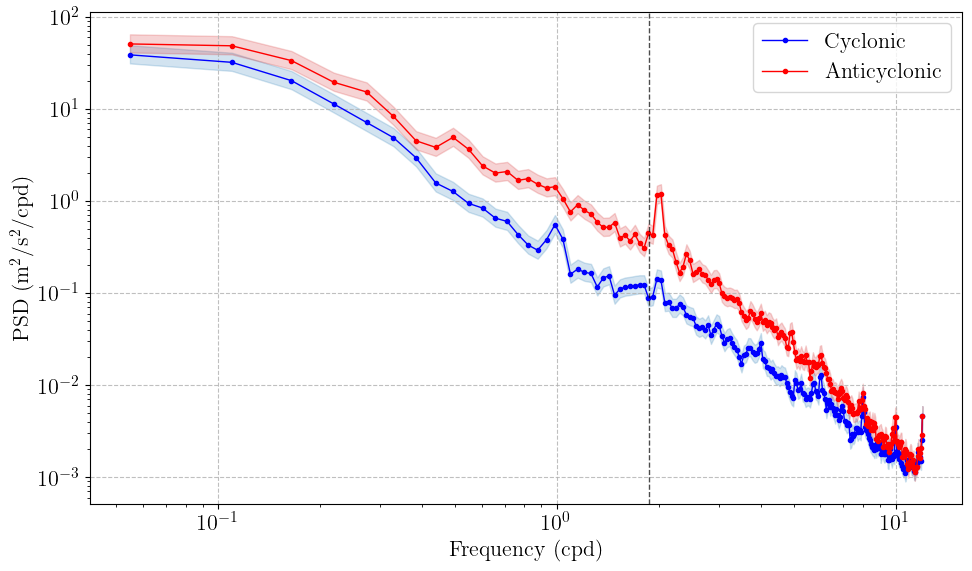

In [28]:
# Create the figure with taller aspect ratio
fig,ax = plt.subplots(figsize=(10, 6))  

# Plot rotary spectra  
ax.loglog(f_cpd[1:], psd_plus_ccw[1:], '.-', color='blue', linewidth=1, label='Cyclonic')
ax.loglog(f_cpd[1:], psd_minus_cw[1:], '.-', color='red', linewidth=1, label='Anticyclonic')

# Plot 95% confidence intervals
ax.fill_between(f_cpd[1:], CIp_ccw[1:, 0], CIp_ccw[1:, 1], color='tab:blue', alpha=0.2)
ax.fill_between(f_cpd[1:], CIm_cw[1:, 0], CIm_cw[1:, 1], color='tab:red', alpha=0.2)

# Plot inertial frequency 
f_inertial = np.abs(lat[0]) / 17.4533  # cpd
ax.axvline(f_inertial, lw = 1, color='k', ls='--', alpha = 0.7)

# Set figure attributes
ax.set_xlabel(r'Frequency (cpd)')
ax.set_ylabel(r'PSD (m$^2$/s$^{2}$/cpd)')
ax.grid(True, linestyle='--', alpha=0.8)
ax.legend()

# Display figure
plt.tight_layout()
plt.show()

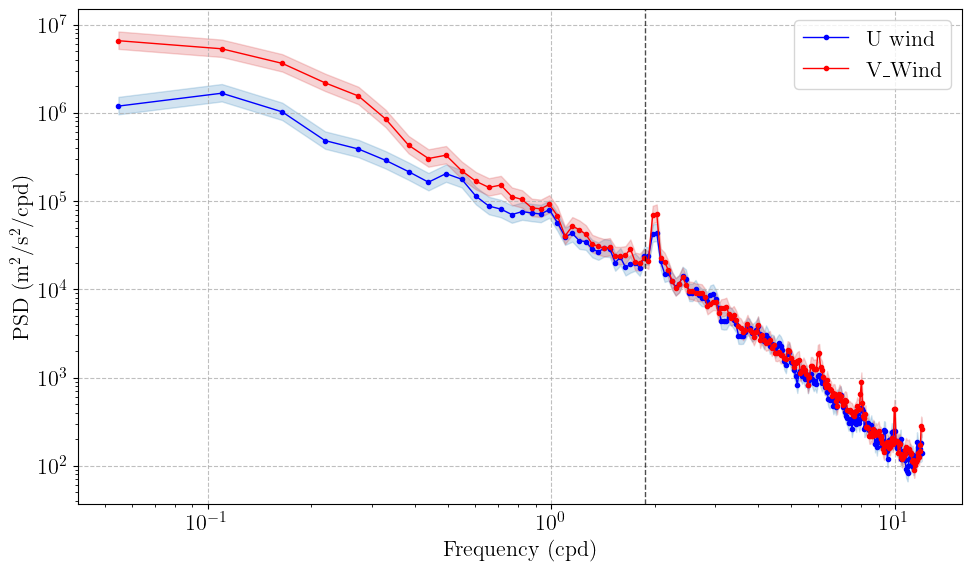

In [29]:
# Set parameters
f_cpd_t = f_cps *(60)*(60)*24

# Create the figure with taller aspect ratio
fig,ax = plt.subplots(figsize=(10, 6))  

# Plot rotary spectra  
ax.loglog(f_cpd_t[1:], psd_u[1:], '.-', color='blue', linewidth=1, label='U wind')
ax.loglog(f_cpd_t[1:], psd_v[1:], '.-', color='red', linewidth=1, label='V_Wind')

# Plot 95% confidence intervals
ax.fill_between(f_cpd_t[1:], CI_u[1:, 0], CI_u[1:, 1], color='tab:blue', alpha=0.2)
ax.fill_between(f_cpd_t[1:], CI_v[1:, 0], CI_v[1:, 1], color='tab:red', alpha=0.2)

# Plot inertial frequency 
f_inertial = np.abs(lat[0]) / 17.4533  # cpd
ax.axvline(f_inertial, lw = 1, color='k', ls='--', alpha = 0.7)

# Set figure attributes
ax.set_xlabel(r'Frequency (cpd)')
ax.set_ylabel(r'PSD (m$^2$/s$^{2}$/cpd)')
ax.grid(True, linestyle='--', alpha=0.8)
ax.legend()

# Display figure
plt.tight_layout()
plt.show()